In [1]:
import json, os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

random.seed(42)
np.random.seed(42)

# ============================================================
# PATHS — hardcoded, no config file needed
# ============================================================
OUTPUT_PATH        = '/kaggle/working'
DATASET_PATH_LOCAL = '/kaggle/working/dermnet_data'

# ============================================================
# STEP 1: Copy dataset if not already copied
# ============================================================
if not os.path.exists(DATASET_PATH_LOCAL):
    print("⚠️  dermnet_data not found. Searching /kaggle/input for dataset...\n")

    DATASET_PATH_INPUT = None
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'train' in dirs and 'test' in dirs:
            DATASET_PATH_INPUT = root
            break

    if DATASET_PATH_INPUT is None:
        # Print tree to help user find the correct path
        print("📂 Contents of /kaggle/input:")
        for root, dirs, files in os.walk('/kaggle/input'):
            depth = root.replace('/kaggle/input', '').count(os.sep)
            if depth > 3:
                dirs.clear()
                continue
            print('   ' * depth + os.path.basename(root) + '/')
        raise FileNotFoundError(
            "\nCannot find dataset. Look at the tree above and set DATASET_PATH_INPUT manually."
        )

    print(f"✓ Found dataset at: {DATASET_PATH_INPUT}")
    print(f"Copying to {DATASET_PATH_LOCAL} ... (may take a few minutes)")
    shutil.copytree(DATASET_PATH_INPUT, DATASET_PATH_LOCAL)
    print("✓ Copy complete!")
else:
    print(f"✓ Dataset already exists: {DATASET_PATH_LOCAL}")

# ============================================================
# STEP 2: Auto-create val/ split if missing
# ============================================================
train_path = os.path.join(DATASET_PATH_LOCAL, 'train')
val_path   = os.path.join(DATASET_PATH_LOCAL, 'val')
test_path  = os.path.join(DATASET_PATH_LOCAL, 'test')

def count_imgs(path):
    total = 0
    if os.path.exists(path):
        for cls in os.listdir(path):
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                total += len([f for f in os.listdir(cls_path)
                              if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

if count_imgs(val_path) == 0:
    print("\n⚠️  val/ missing — creating 80/20 split from train/...")
    os.makedirs(val_path, exist_ok=True)
    classes = [d for d in os.listdir(train_path)
               if os.path.isdir(os.path.join(train_path, d))]
    total_moved = 0
    for class_name in tqdm(classes, desc="Splitting val"):
        train_cls = os.path.join(train_path, class_name)
        val_cls   = os.path.join(val_path, class_name)
        os.makedirs(val_cls, exist_ok=True)
        images = [f for f in os.listdir(train_cls)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if len(images) >= 5:
            _, v_imgs = train_test_split(images, test_size=0.2, random_state=42)
            for img in v_imgs:
                shutil.move(os.path.join(train_cls, img),
                            os.path.join(val_cls, img))
            total_moved += len(v_imgs)
    print(f"✓ val/ created — {total_moved} images moved")
else:
    print(f"\n✓ val/ exists — {count_imgs(val_path)} images")

# ============================================================
# STEP 3: Verify all 3 splits
# ============================================================
print()
all_ok = True
for split, path in [('train', train_path), ('val', val_path), ('test', test_path)]:
    n = count_imgs(path)
    if n > 0:
        n_cls = len([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
        print(f"✓ {split:6s}/ — {n_cls} classes, {n} images")
    else:
        print(f"❌ {split}/ MISSING at: {path}")
        all_ok = False

if not all_ok:
    raise FileNotFoundError("Split folders missing. Check your dataset.")

# Save config for later notebooks
config = {
    'DATASET_PATH_LOCAL': DATASET_PATH_LOCAL,
    'OUTPUT_PATH': OUTPUT_PATH
}
with open(os.path.join(OUTPUT_PATH, 'paths_config.json'), 'w') as f:
    json.dump(config, f, indent=4)

print(f"\nTensorFlow: {tf.__version__}")
print("✓ All done — ready for next cells!")

2026-02-18 16:21:00.549734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771431660.724583      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771431660.787167      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771431661.224046      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771431661.224099      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771431661.224101      24 computation_placer.cc:177] computation placer alr

⚠️  dermnet_data not found. Searching /kaggle/input for dataset...

✓ Found dataset at: /kaggle/input/notebooks/kevinchovatiya/04-train-val-split-ipynb/dermnet_data
Copying to /kaggle/working/dermnet_data ... (may take a few minutes)
✓ Copy complete!

✓ val/ exists — 3119 images

✓ train / — 23 classes, 12438 images
✓ val   / — 23 classes, 3119 images
✓ test  / — 23 classes, 4002 images

TensorFlow: 2.19.0
✓ All done — ready for next cells!


In [2]:
# ========================================
# CUSTOMIZE THESE: Augmentation Parameters
# ========================================

AUGMENTATION_CONFIG = {
    'rotation_range': 20,
    'width_shift_range': 0.2,
    'height_shift_range': 0.2,
    'shear_range': 0.15,
    'zoom_range': 0.2,
    'horizontal_flip': True,
    'vertical_flip': False,
    'fill_mode': 'nearest',
    'brightness_range': [0.8, 1.2],
}

print("Augmentation Configuration:")
print("=" * 50)
for key, value in AUGMENTATION_CONFIG.items():
    print(f"   {key:<25} {value}")
print("=" * 50)

Augmentation Configuration:
   rotation_range            20
   width_shift_range         0.2
   height_shift_range        0.2
   shear_range               0.15
   zoom_range                0.2
   horizontal_flip           True
   vertical_flip             False
   fill_mode                 nearest
   brightness_range          [0.8, 1.2]


In [3]:
TARGET_SIZE = (224, 224)
BATCH_SIZE  = 16

print(f"✓ Target Image Size: {TARGET_SIZE}")
print(f"✓ Batch Size: {BATCH_SIZE}")

✓ Target Image Size: (224, 224)
✓ Batch Size: 16


In [4]:
train_datagen = ImageDataGenerator(rescale=1./255, **AUGMENTATION_CONFIG)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

print("✓ Data generators created!")

✓ Data generators created!


In [5]:
# ============================================================
# Re-load paths (safe to re-run)
# ============================================================
with open('/kaggle/working/paths_config.json') as f:
    paths = json.load(f)

DATASET_PATH_LOCAL = paths.get('DATASET_PATH_LOCAL', '/kaggle/working/dermnet_data')
OUTPUT_PATH = paths.get('OUTPUT_PATH', '/kaggle/working')

train_path = os.path.join(DATASET_PATH_LOCAL, 'train')
val_path   = os.path.join(DATASET_PATH_LOCAL, 'val')
test_path  = os.path.join(DATASET_PATH_LOCAL, 'test')

# ============================================================
# Load generators
# ============================================================
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print(f"\n✓ All generators loaded!")
print(f"   Train : {train_generator.samples} samples")
print(f"   Val   : {val_generator.samples} samples")
print(f"   Test  : {test_generator.samples} samples")
print(f"   Classes: {train_generator.num_classes}")

Found 12438 images belonging to 23 classes.
Found 3119 images belonging to 23 classes.
Found 4002 images belonging to 23 classes.

✓ All generators loaded!
   Train : 12438 samples
   Val   : 3119 samples
   Test  : 4002 samples
   Classes: 23


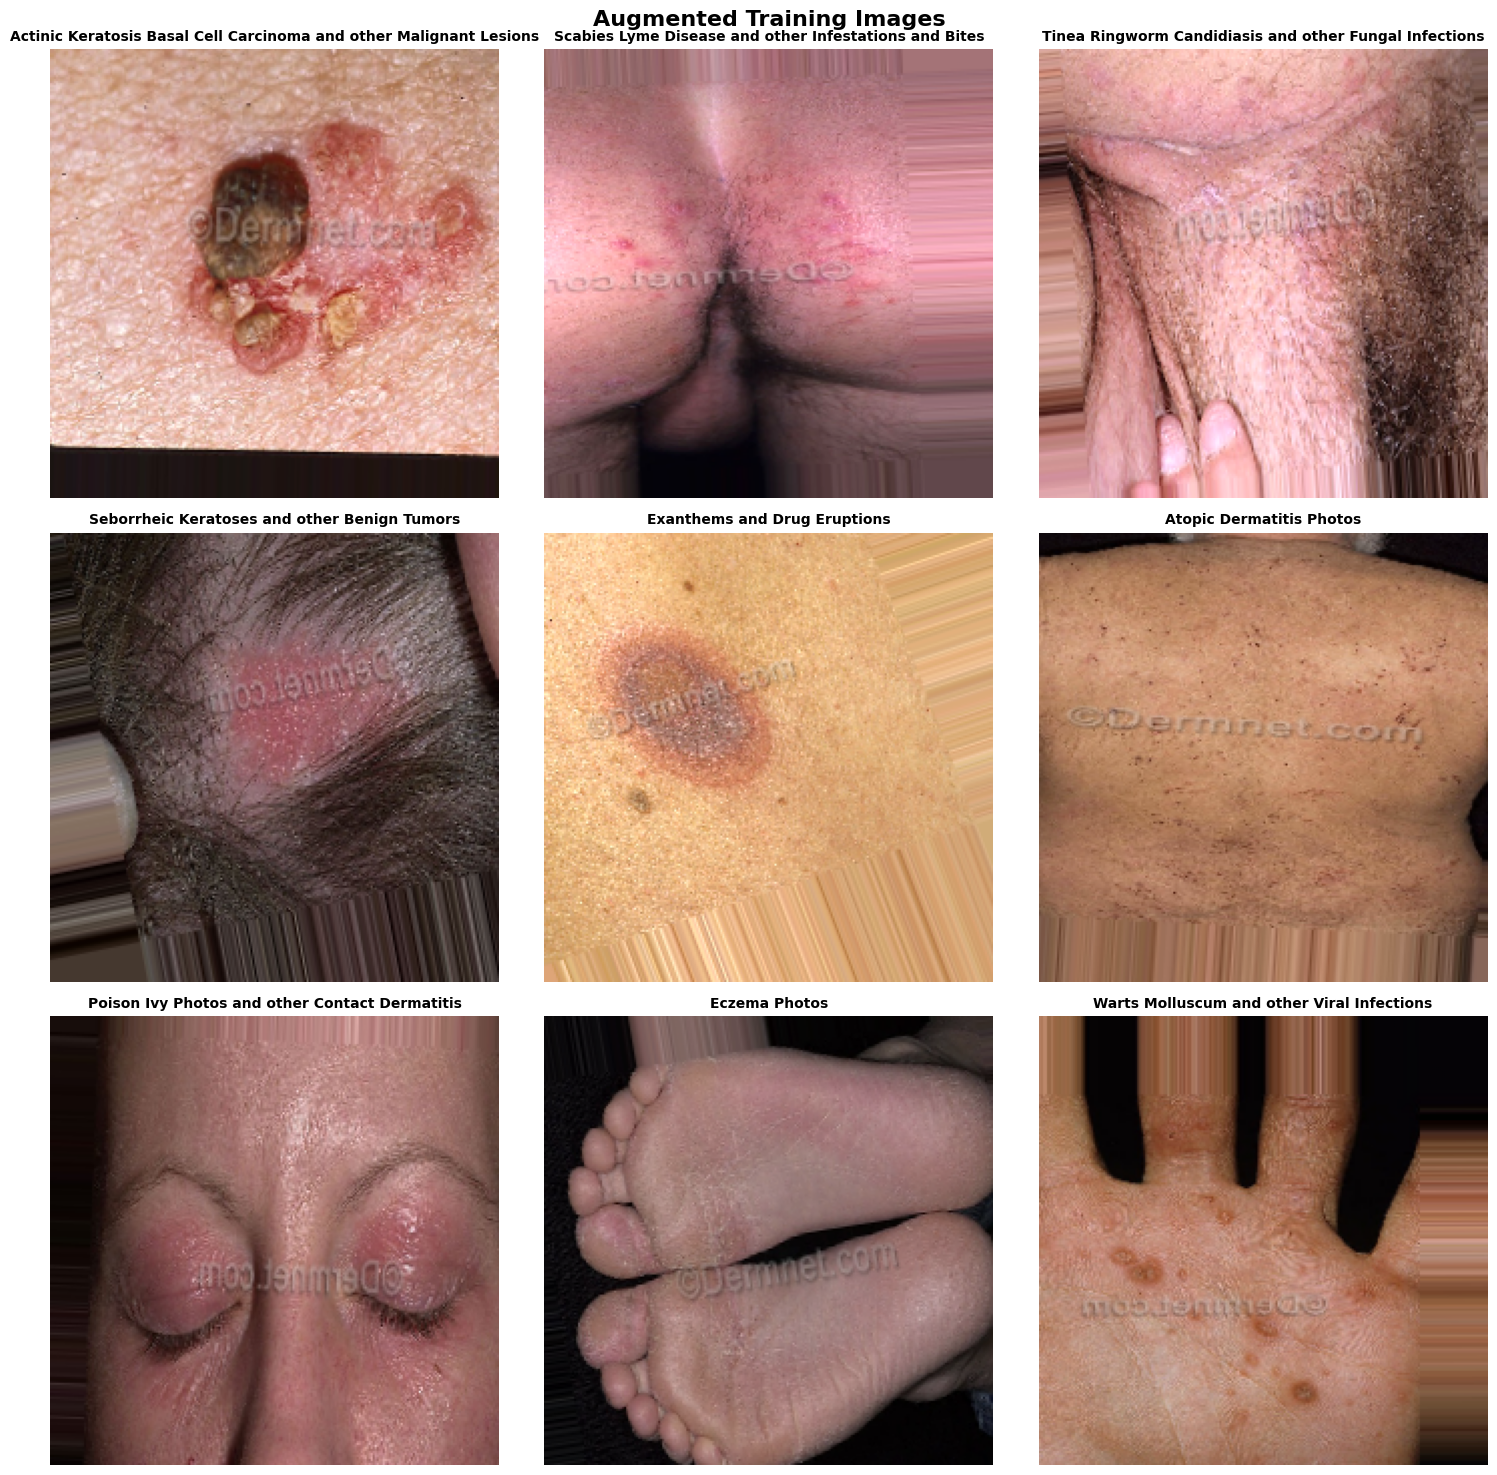

✓ Saved: /kaggle/working/augmented_samples.png


In [6]:
def visualize_augmentation(generator, num_images=9):
    images, labels = next(generator)
    grid_size = int(np.ceil(np.sqrt(num_images)))
    class_names = list(generator.class_indices.keys())

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    axes = axes.flatten()

    for i in range(num_images):
        if i < len(images):
            axes[i].imshow(images[i])
            axes[i].set_title(class_names[np.argmax(labels[i])], fontsize=10, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.suptitle('Augmented Training Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_PATH, 'augmented_samples.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {save_path}")

visualize_augmentation(train_generator, num_images=9)

Using class: Acne and Rosacea Photos


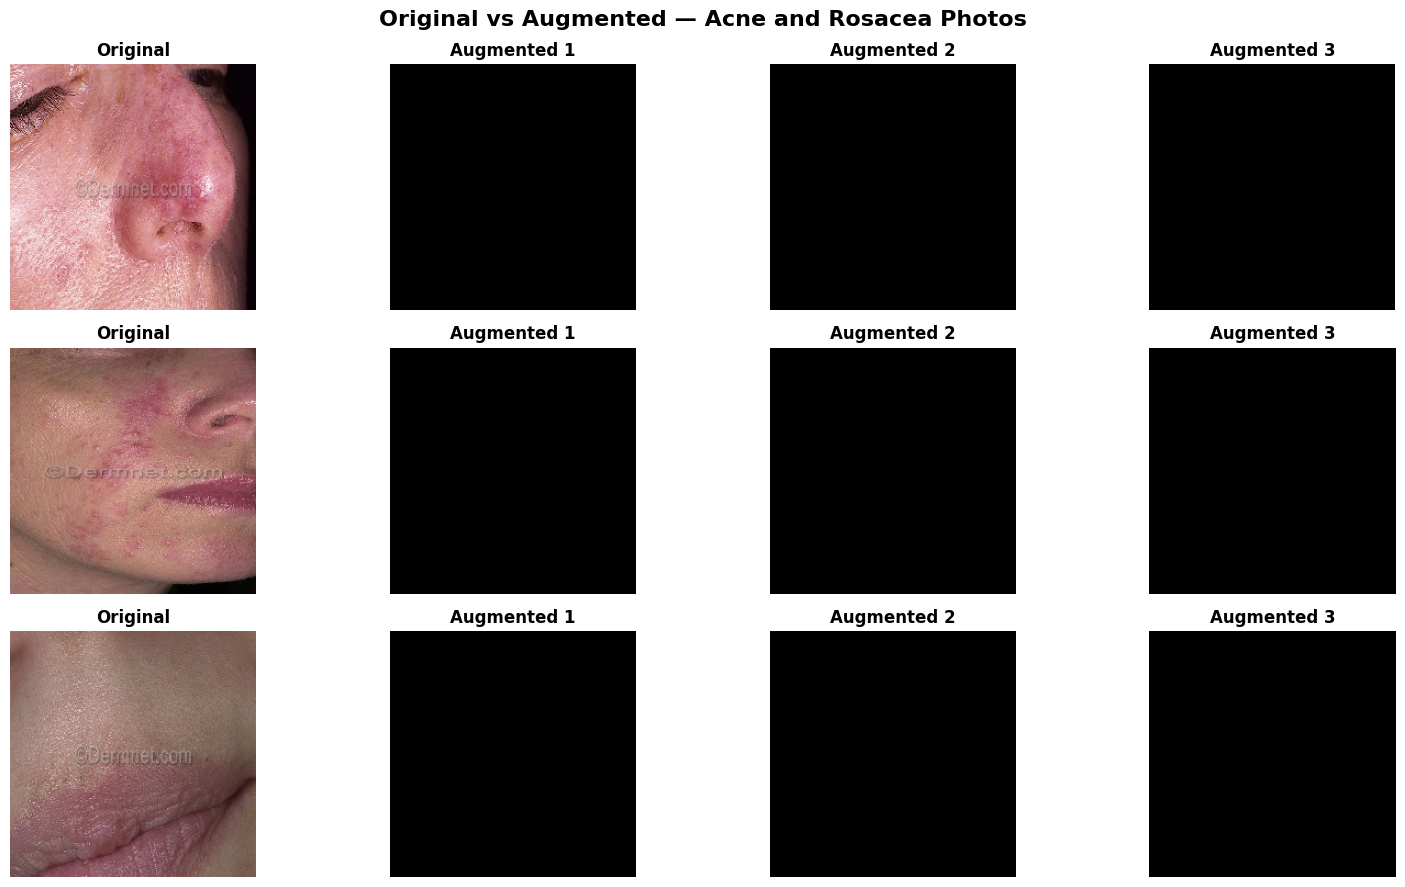

✓ Saved: /kaggle/working/comparison_Acne and Rosacea Photos.png


In [7]:
def compare_original_vs_augmented(class_name, original_path, num_samples=3):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array

    class_path = os.path.join(original_path, 'train', class_name)
    if not os.path.exists(class_path):
        print(f"Error: Class '{class_name}' not found.")
        print(f"Available: {list(train_generator.class_indices.keys())}")
        return

    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = np.random.choice(images, min(num_samples, len(images)), replace=False)

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 3))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i, img_name in enumerate(samples):
        img_path = os.path.join(class_path, img_name)
        img_array = load_img(img_path, target_size=TARGET_SIZE)
        img_array = np.array(img_array) / 255.0

        axes[i, 0].imshow(img_array)
        axes[i, 0].set_title('Original', fontweight='bold')
        axes[i, 0].axis('off')

        aug_gen = train_datagen.flow(np.expand_dims(img_array, 0), batch_size=1)
        for j in range(3):
            aug_img = next(aug_gen)[0]
            axes[i, j+1].imshow(aug_img)
            axes[i, j+1].set_title(f'Augmented {j+1}', fontweight='bold')
            axes[i, j+1].axis('off')

    plt.suptitle(f'Original vs Augmented — {class_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_PATH, f'comparison_{class_name}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {save_path}")

first_class = list(train_generator.class_indices.keys())[0]
print(f"Using class: {first_class}")
compare_original_vs_augmented(first_class, DATASET_PATH_LOCAL, num_samples=3)

In [8]:
def save_class_mapping(generator, output_path):
    class_mapping = generator.class_indices
    index_to_class = {str(v): k for k, v in class_mapping.items()}

    mapping_data = {
        'class_to_index': class_mapping,
        'index_to_class': index_to_class,
        'num_classes': len(class_mapping)
    }

    with open(output_path, 'w') as f:
        json.dump(mapping_data, f, indent=4)

    print(f"✓ Class mapping saved to: {output_path}")
    print("\nClass Mapping:")
    print("=" * 40)
    for class_name, idx in sorted(class_mapping.items(), key=lambda x: x[1]):
        print(f"   {idx:2d}: {class_name}")
    print("=" * 40)
    return mapping_data

class_mapping = save_class_mapping(
    train_generator,
    os.path.join(OUTPUT_PATH, 'class_mapping.json')
)

✓ Class mapping saved to: /kaggle/working/class_mapping.json

Class Mapping:
    0: Acne and Rosacea Photos
    1: Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
    2: Atopic Dermatitis Photos
    3: Bullous Disease Photos
    4: Cellulitis Impetigo and other Bacterial Infections
    5: Eczema Photos
    6: Exanthems and Drug Eruptions
    7: Hair Loss Photos Alopecia and other Hair Diseases
    8: Herpes HPV and other STDs Photos
    9: Light Diseases and Disorders of Pigmentation
   10: Lupus and other Connective Tissue diseases
   11: Melanoma Skin Cancer Nevi and Moles
   12: Nail Fungus and other Nail Disease
   13: Poison Ivy Photos and other Contact Dermatitis
   14: Psoriasis pictures Lichen Planus and related diseases
   15: Scabies Lyme Disease and other Infestations and Bites
   16: Seborrheic Keratoses and other Benign Tumors
   17: Systemic Disease
   18: Tinea Ringworm Candidiasis and other Fungal Infections
   19: Urticaria Hives
   20: Vascular Tumo

In [9]:
summary = f"""
{'='*70}
DATA PREPROCESSING SUMMARY
{'='*70}

Dataset Information:
   • Dataset Path: {DATASET_PATH_LOCAL}
   • Number of Classes: {train_generator.num_classes}
   • Target Image Size: {TARGET_SIZE}
   • Batch Size: {BATCH_SIZE}

Split Distribution:
   • Training Samples:   {train_generator.samples}
   • Validation Samples: {val_generator.samples}
   • Testing Samples:    {test_generator.samples}
   • Total Samples:      {train_generator.samples + val_generator.samples + test_generator.samples}

Augmentation Parameters:
"""

for key, value in AUGMENTATION_CONFIG.items():
    summary += f"   • {key}: {value}\n"

summary += f"""
Class Distribution:
"""
for class_name, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    summary += f"   {idx:2d}. {class_name}\n"

summary += f"\n{'='*70}\n"

print(summary)

save_path = os.path.join(OUTPUT_PATH, 'preprocessing_summary.txt')
with open(save_path, 'w') as f:
    f.write(summary)
print(f"✓ Summary saved to: {save_path}")


DATA PREPROCESSING SUMMARY

Dataset Information:
   • Dataset Path: /kaggle/working/dermnet_data
   • Number of Classes: 23
   • Target Image Size: (224, 224)
   • Batch Size: 16

Split Distribution:
   • Training Samples:   12438
   • Validation Samples: 3119
   • Testing Samples:    4002
   • Total Samples:      19559

Augmentation Parameters:
   • rotation_range: 20
   • width_shift_range: 0.2
   • height_shift_range: 0.2
   • shear_range: 0.15
   • zoom_range: 0.2
   • horizontal_flip: True
   • vertical_flip: False
   • fill_mode: nearest
   • brightness_range: [0.8, 1.2]

Class Distribution:
    0. Acne and Rosacea Photos
    1. Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
    2. Atopic Dermatitis Photos
    3. Bullous Disease Photos
    4. Cellulitis Impetigo and other Bacterial Infections
    5. Eczema Photos
    6. Exanthems and Drug Eruptions
    7. Hair Loss Photos Alopecia and other Hair Diseases
    8. Herpes HPV and other STDs Photos
    9. Light Di